# Demo del Pipeline Completo (Sprint 3)

Este notebook demuestra la ejecución paso a paso del pipeline de Machine Learning para el Forecast de Ingresos.
El proceso es modular y cubre:

1.  **Generación de la Master Table**: Carga de datos raw y construcción del dataset base.
2.  **Ingeniería de Características**: Generación de lags, rolling windows y estacionalidad.
3.  **Selección de Características**: Filtrado estadístico (Variance, Correlación, SelectKBest).
4.  **Tuning & Cross-Validation**: Búsqueda de hiperparámetros con TimeSeriesSplit.
5.  **Exportación del Modelo**: Guardado del mejor modelo (`.pkl`).
6.  **Inferencia**: Prueba del modelo con datos.

In [1]:
# 1. Setup e Importaciones
import sys
import os
from pathlib import Path
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar src al path para importar módulos
sys.path.append(os.path.abspath("../src"))

from forecast_income.utils.config import load_config
from forecast_income.utils.logger import get_logger
from forecast_income.data.load_raw import load_raw_data
from forecast_income.data.build_monthly_table import build_master_table_monthly
from forecast_income.features.feature_engineering import FeatureConfig, make_supervised_monthly
from forecast_income.features.selection import select_features
from forecast_income.models.tune import perform_tuning, _split_train_test, _save_plots

# Configuración
LOGGER = get_logger("notebook_demo")
params = load_config("../config/params.yaml")
print("✅ Configuración cargada correctamente.")

✅ Configuración cargada correctamente.


In [2]:
# 2. Generación de la Master Table
# Paso 1: Cargar datos raw (desde caché o URL)
print("📥 Cargando datos raw...")
raw_data = load_raw_data(params["data"]["base_url"], cache_dir="../data/raw")

# Paso 2: Construir Master Table Mensual
print("🏗️ Construyendo Master Table Mensual...")
df_master = build_master_table_monthly(raw_data)

# Guardar para referencia (opcional)
master_path = Path("../data/processed/master_table_demo.csv")
master_path.parent.mkdir(parents=True, exist_ok=True)
df_master.to_csv(master_path, index=False)

print(f"✅ Master Table generada: {df_master.shape}")
df_master.tail()

[INFO] forecast_income.data.load_raw: Leyendo orders desde caché: ../data/raw/olist_orders_dataset.csv


📥 Cargando datos raw...


[INFO] forecast_income.data.load_raw: Leyendo payments desde caché: ../data/raw/olist_order_payments_dataset.csv
[INFO] forecast_income.data.load_raw: Leyendo items desde caché: ../data/raw/olist_order_items_dataset.csv
[INFO] forecast_income.data.load_raw: Leyendo items desde caché: ../data/raw/olist_order_items_dataset.csv
[INFO] forecast_income.data.load_raw: Leyendo customers desde caché: ../data/raw/olist_customers_dataset.csv
[INFO] forecast_income.data.load_raw: Leyendo customers desde caché: ../data/raw/olist_customers_dataset.csv
[INFO] forecast_income.data.load_raw: Leyendo products desde caché: ../data/raw/olist_products_dataset.csv
[INFO] forecast_income.data.load_raw: Leyendo products desde caché: ../data/raw/olist_products_dataset.csv
[INFO] forecast_income.data.load_raw: Leyendo sellers desde caché: ../data/raw/olist_sellers_dataset.csv
[INFO] forecast_income.data.load_raw: Leyendo reviews desde caché: ../data/raw/olist_order_reviews_dataset.csv
[INFO] forecast_income.da

🏗️ Construyendo Master Table Mensual...
✅ Master Table generada: (22, 13)
✅ Master Table generada: (22, 13)


,month,monthly_revenue,total_orders,avg_review_score,active_days,total_items,total_freight,unique_customers,avg_installments,top_category,new_sellers,year,month_num
17,2018-03-01,1159652.12,7211,3.753567,31,8217.0,171913.38,7115,2.878835,cama_mesa_banho,113,2018,3
18,2018-04-01,1160785.48,6939,4.162502,30,7975.0,163050.29,6882,2.741159,cama_mesa_banho,202,2018,4
19,2018-05-01,1153982.15,6873,4.194034,31,7925.0,153264.14,6814,2.875261,beleza_saude,172,2018,5
20,2018-06-01,1023880.50,6167,4.277479,30,7078.0,157552.80,6128,2.864818,beleza_saude,191,2018,6
21,2018-07-01,1066540.75,6292,4.263246,31,7092.0,163220.81,6230,2.746345,beleza_saude,190,2018,7


In [3]:
# 3. Ingeniería de Características
# Definir configuración de features
cfg = FeatureConfig(
    base_cols=params["features"]["base_cols"],
    lags=params["features"]["lags"],
    rolling_windows=params["features"]["rolling_windows"],
    add_seasonality=params["features"]["add_seasonality"],
    add_trend=params["features"]["add_trend"],
    target_col=params["features"]["target_col"],
)

print("⚙️ Generando Features (Lags, Rolling, Seasonality)...")
X, y, feature_names, dates = make_supervised_monthly(df_master, cfg)

# Guardar features generadas para inspección
features_path = Path("../data/processed/features_generated_demo.csv")
full_dataset = X.copy()
full_dataset["target"] = y
full_dataset["date_index"] = dates
full_dataset.to_csv(features_path, index=False)

print(f"✅ Features Generadas: {X.shape[1]} columnas")
print(f"   Guardado en: {features_path}")
X.head()

⚙️ Generando Features (Lags, Rolling, Seasonality)...
Total features generated: 95
✅ Features Generadas: 95 columnas
   Guardado en: ../data/processed/features_generated_demo.csv


,monthly_revenue_lag_1,monthly_revenue_lag_2,monthly_revenue_lag_3,monthly_revenue_lag_6,monthly_revenue_roll_mean_3,monthly_revenue_roll_std_3,monthly_revenue_roll_min_3,monthly_revenue_roll_max_3,monthly_revenue_roll_mean_6,monthly_revenue_roll_std_6,...,avg_installments_roll_max_3,avg_installments_roll_mean_6,avg_installments_roll_std_6,avg_installments_roll_min_6,avg_installments_roll_max_6,avg_installments_pct_change,quarter,month_num,month_sin,month_cos
0,449863.60,291908.01,138488.04,252.24,293419.883333,155693.285539,138488.04,449863.60,156603.665000,180615.604873,...,3.013750,2.578465,0.939267,1.000000,3.666667,0.051730,2,4,8.660254e-01,-0.500000
1,417788.03,449863.60,291908.01,59090.48,386519.880000,83491.107349,291908.01,449863.60,226192.963333,188587.096793,...,3.143530,2.769053,0.914095,1.000000,3.666667,0.059075,2,5,5.000000e-01,-0.866025
2,592918.82,417788.03,449863.60,19.62,486856.816667,93242.007491,417788.03,592918.82,315164.353333,217667.007130,...,3.345901,2.715592,0.858806,1.000000,3.345901,0.064377,2,6,1.224647e-16,-1.000000
3,511276.38,592918.82,417788.03,138488.04,507327.743333,87632.141365,417788.03,592918.82,400373.813333,162772.504791,...,3.345901,3.090223,0.192677,2.822191,3.345901,-0.029324,3,7,-5.000000e-01,-0.866025
4,592382.92,511276.38,592918.82,291908.01,565526.040000,46982.347800,511276.38,592918.82,476022.960000,115257.121254,...,3.345901,3.129858,0.198180,2.822191,3.345901,0.001163,3,8,-8.660254e-01,-0.500000


In [4]:
# 4. Selección de Características y Split
# Configuración del Split según requerimientos del Sprint 3:
# - Train: Hasta 2018-04 (Entrenamiento)
# - Backtest (Test): 2018-05, 2018-06, 2018-07 (Inputs) -> Predicen: Junio, Julio, Agosto (Target)
#   *Nota*: Si queremos predecir el target de Mayo, Junio, Julio, los inputs son Abril, Mayo, Junio.
#   Ajustamos para tener 3 meses de prueba finales en el dataset recortado.

# Para tener Mayo, Junio y Julio como meses de PRUEBA (Test), cortamos en Julio.
cutoff = "2018-07-01" 
test_size = 3

print(f"📅 Filtrando datos hasta {cutoff} para Backtest")
if cutoff:
    mask = dates <= cutoff
    X = X[mask]
    y = y[mask]
    dates = dates[mask]

X_train, X_test, y_train, y_test = _split_train_test(X, y, test_size)
print(f"📊 Split: Train={len(X_train)} (hasta {dates.iloc[len(X_train)-1].date()}), Test={len(X_test)} (desde {dates.iloc[len(X_train)].date()})")

# Selección de Features (Pipeline Estricto)
print("\n🔍 Ejecutando Selección de Features (Variance -> Corr -> SelectKBest)...")
X_train_sel, selected_cols = select_features(X_train, y_train, random_state=42)
X_test_sel = X_test[selected_cols]

print(f"✅ Features Seleccionadas ({len(selected_cols)}): {selected_cols}")

# Generar gráficos de justificación
_save_plots(X_train_sel, y_train, "../reports/figures_demo")
print("📈 Gráficos guardados en reports/figures_demo")

[INFO] forecast_income.features.selection: Inicio selección de features. Shape original: (12, 95)
[INFO] forecast_income.features.selection: Features tras VarianceThreshold: 95
[INFO] forecast_income.features.selection: Features tras filtro correlación (>0.70): 7
[INFO] forecast_income.features.selection: Columnas eliminadas por correlación: 88
[INFO] forecast_income.features.selection: Features tras VarianceThreshold: 95
[INFO] forecast_income.features.selection: Features tras filtro correlación (>0.70): 7
[INFO] forecast_income.features.selection: Columnas eliminadas por correlación: 88


📅 Filtrando datos hasta 2018-07-01 para Backtest
📊 Split: Train=12 (hasta 2018-03-01), Test=3 (desde 2018-04-01)

🔍 Ejecutando Selección de Features (Variance -> Corr -> SelectKBest)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_selection/_rfe.py:839: UserWarning: Found min_features_to_select=12 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(
[INFO] forecast_income.features.selection: Features tras RFECV: 7
[INFO] forecast_income.features.selection: Features tras RFECV: 7
[INFO] forecast_income.features.selection: Top 20 Features más importantes:
[INFO] forecast_income.features.selection: 
monthly_revenue_lag_1          0.572063
avg_installments_lag_6         0.192968
monthly_revenue_roll_std_3     0.066059
avg_review_score_pct_change    0.064313
avg_review_score_lag_6         0.045835
monthly_revenue_pct_change     0.032961
avg_review_score_lag_3         0.025802
dtype: float64
[INFO] forecast_income.features.selection: Top 20 Features más importantes:
[INFO] forecast_income.features.selection: 
monthly_revenue_lag_1          0.572063
avg_installments_lag_6        

✅ Features Seleccionadas (7): ['monthly_revenue_lag_1', 'monthly_revenue_roll_std_3', 'monthly_revenue_pct_change', 'avg_review_score_lag_3', 'avg_review_score_lag_6', 'avg_review_score_pct_change', 'avg_installments_lag_6']
📈 Gráficos guardados en reports/figures_demo
📈 Gráficos guardados en reports/figures_demo


In [5]:
# 5. Hyperparameter Tuning & Cross-Validation
print("🎛️ Iniciando Tuning de Modelos con TimeSeriesSplit...")

# Ejecutar Tuning (Ridge, RF, GBM)
# Nota: Los modelos 'Naive' se calculan como REFERENCIA (Benchmark).
# El pipeline seleccionará el mejor modelo de ML (que usa features) para exportar.
results, best_info = perform_tuning(X_train_sel, y_train, X_test_sel, y_test, params)

# Mostrar Resultados
df_results = pd.DataFrame(results).sort_values("MAPE")
print("\n🏆 Resultados del Tuning:")
display(df_results)

best_model_name = best_info["best_model_name"]
best_mape = best_info["best_mape"]
print(f"\n✅ Mejor Modelo ML Seleccionado: {best_model_name} (MAPE: {best_mape:.2f}%)")

# Verificación contra Benchmark
naive_mape = df_results[df_results["model"] == "naive_last"]["MAPE"].values[0]
if naive_mape < best_mape:
    print(f"⚠️ Nota: El modelo Naive ({naive_mape:.2f}%) supera al ML. Esto indica alta inercia en la serie.")
else:
    print(f"🎉 El modelo ML supera al Benchmark Naive ({naive_mape:.2f}%).")

[INFO] forecast_income.models.tune: ⚙️ Tuning: ridge


🎛️ Iniciando Tuning de Modelos con TimeSeriesSplit...


[INFO] forecast_income.models.tune:    ✅ Resultado ridge: MAPE Test=11.56% | CV Score (Mean MAPE)=0.19%
[INFO] forecast_income.models.tune:    ℹ️ Mejores Parámetros: {'model__alpha': 1.0}
[INFO] forecast_income.models.tune: ⚙️ Tuning: random_forest
[INFO] forecast_income.models.tune:    ℹ️ Mejores Parámetros: {'model__alpha': 1.0}
[INFO] forecast_income.models.tune: ⚙️ Tuning: random_forest
[INFO] forecast_income.models.tune:    ✅ Resultado random_forest: MAPE Test=8.19% | CV Score (Mean MAPE)=0.22%
[INFO] forecast_income.models.tune:    ℹ️ Mejores Parámetros: {'max_depth': 5, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2}
[INFO] forecast_income.models.tune: ⚙️ Tuning: gradient_boosting
[INFO] forecast_income.models.tune:    ✅ Resultado random_forest: MAPE Test=8.19% | CV Score (Mean MAPE)=0.22%
[INFO] forecast_income.models.tune:    ℹ️ Mejores Parámetros: {'max_depth': 5, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2}
[INFO] forecast_income.mo


🏆 Resultados del Tuning:


,model,MAE,RMSE,MAPE,Bias,best_params
0,naive_last,57587.300000,79049.217291,5.091339,-57587.300000,NaN
3,gradient_boosting,80376.999510,98537.200736,7.706291,80376.999510,"{'learning_rate': 0.01, 'max_depth': 4, 'n_est..."
2,random_forest,90551.085042,102600.665916,8.189135,-90551.085042,"{'max_depth': 5, 'max_features': 0.8, 'min_sam..."
1,ridge,123676.258460,128793.951030,11.558619,123676.258460,{'model__alpha': 1.0}



✅ Mejor Modelo ML Seleccionado: gradient_boosting (MAPE: 7.71%)
⚠️ Nota: El modelo Naive (5.09%) supera al ML. Esto indica alta inercia en la serie.


In [6]:
# 6. Exportación del Modelo
best_estimator = best_info["best_estimator"]

export_path = Path("../models/final/model_demo.pkl")
export_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_estimator, export_path)
print(f"💾 Modelo guardado en: {export_path}")

# Guardar metadatos de features
import json
(export_path.parent / "selected_features_demo.json").write_text(json.dumps(selected_cols, indent=2))
print("💾 Features seleccionadas guardadas.")

💾 Modelo guardado en: ../models/final/model_demo.pkl
💾 Features seleccionadas guardadas.


🔮 Ejecutando Backtest en el set de prueba...

📊 Resultados del Backtest (May-Jun-Jul):


,Mes Predicho,Real,Predicción,Error Abs,Error %
0,2018-05-01,1153982.15,1.155052e+06,1069.915356,0.092715
1,2018-06-01,1023880.50,1.156420e+06,132539.203393,12.944792
2,2018-07-01,1066540.75,1.174063e+06,107521.879781,10.081366


MAPE Promedio Backtest: 7.71%


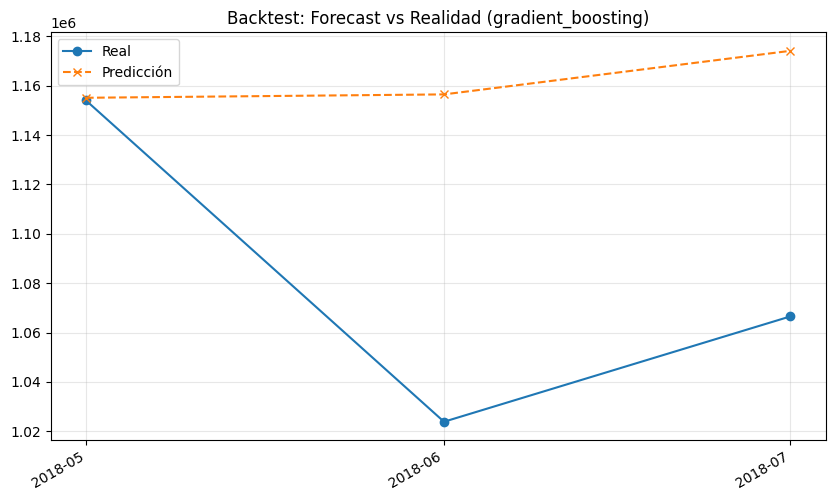

In [7]:
# 7. Validación del Backtest (Mayo, Junio, Julio 2018)
print("🔮 Ejecutando Backtest en el set de prueba...")

# Cargar modelo
loaded_model = joblib.load(export_path)

# Predecir
preds = loaded_model.predict(X_test_sel)

# Crear DataFrame comparativo
# Nota: El target de la fila '2018-04-01' es el revenue de '2018-05-01'
# Ajustamos las fechas para mostrar el mes PREDICHO, no el mes input
pred_dates = dates.iloc[-len(y_test):] + pd.DateOffset(months=1)

df_preds = pd.DataFrame({
    "Mes Predicho": pred_dates.values,
    "Real": y_test.values,
    "Predicción": preds,
    "Error Abs": abs(y_test.values - preds),
    "Error %": abs(y_test.values - preds) / y_test.values * 100
})

print("\n📊 Resultados del Backtest (May-Jun-Jul):")
display(df_preds)
print(f"MAPE Promedio Backtest: {df_preds['Error %'].mean():.2f}%")

# Plot
import matplotlib.dates as mdates

plt.figure(figsize=(10, 6))
plt.plot(df_preds["Mes Predicho"], df_preds["Real"], label="Real", marker="o")
plt.plot(df_preds["Mes Predicho"], df_preds["Predicción"], label="Predicción", marker="x", linestyle="--")
plt.title(f"Backtest: Forecast vs Realidad ({best_model_name})")
plt.legend()
plt.grid(True, alpha=0.3)

# Mejorar formato del eje X (Solo Mes-Año) para evitar saturación
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gcf().autofmt_xdate()

plt.show()

In [8]:
# 8. Predicción Final (Agosto 2018)
# Ahora re-entrenamos el modelo con TODOS los datos disponibles (hasta Julio input -> Agosto target)
# para hacer la predicción final "a futuro" (o contra el holdout).

print("🚀 Generando Predicción Final para Agosto 2018...")

# 1. Recuperar datos completos hasta 2018-07-01
# (Re-generamos X, y completos sin el cutoff anterior)
X_full, y_full, _, dates_full = make_supervised_monthly(df_master, cfg)
mask_final = dates_full <= "2018-07-01"
X_final_train = X_full[mask_final]
y_final_train = y_full[mask_final]

# Seleccionar features
X_final_train_sel = X_final_train[selected_cols]

# 2. Re-entrenar mejor modelo
final_model = best_estimator # Usamos la misma configuración (hiperparámetros)
final_model.fit(X_final_train_sel, y_final_train)
print("✅ Modelo re-entrenado con datos hasta Julio 2018.")

# 3. Predecir Agosto 2018
# El input para predecir Agosto es la fila de Julio 2018
last_row = X_final_train_sel.iloc[[-1]]
pred_august = final_model.predict(last_row)[0]

print(f"\n💰 Predicción de Ingresos para AGOSTO 2018: R$ {pred_august:,.2f}")

# (Opcional) Verificar si tenemos el dato real de Agosto para comparar
if len(y_full) > len(y_final_train):
    real_august = y_full.iloc[len(y_final_train)]
    error_aug = abs(real_august - pred_august) / real_august * 100
    print(f"📉 Dato Real Agosto (Holdout): R$ {real_august:,.2f}")
    print(f"⚠️ Error en Holdout: {error_aug:.2f}%")
else:
    print("ℹ️ No hay datos reales de Agosto en el dataset actual para comparar.")

🚀 Generando Predicción Final para Agosto 2018...
Total features generated: 95
✅ Modelo re-entrenado con datos hasta Julio 2018.

💰 Predicción de Ingresos para AGOSTO 2018: R$ 1,066,499.31
ℹ️ No hay datos reales de Agosto en el dataset actual para comparar.
✅ Modelo re-entrenado con datos hasta Julio 2018.

💰 Predicción de Ingresos para AGOSTO 2018: R$ 1,066,499.31
ℹ️ No hay datos reales de Agosto en el dataset actual para comparar.
